# 1965 Fuzzy Logic

Lotfi Zadeh introduced fuzzy sets in 1965 as a way to represent concepts that are true by degree instead of only true or false. This makes fuzzy logic useful when a system has to reason with words like "warm", "fast", or "acceptable" instead of crisp categories.

## High-Level Ideas

Classical Boolean logic treats a statement as either `0` or `1`. Fuzzy logic lets a value belong to a set with any membership grade between `0` and `1`.

- **Fuzzy set**: a category whose boundary is gradual, such as `warm temperature`.
- **Membership function**: a function that maps an input to a grade in `[0, 1]`.
- **Fuzzy rule**: a readable rule such as `IF temperature is warm THEN fan speed is medium`.
- **Defuzzification**: turning fuzzy conclusions back into one crisp value.

For a fuzzy set `A`, the membership of `x` is written as:

$$\mu_A(x) \in [0, 1]$$

Common fuzzy operators use simple min/max formulas:

$$NOT(A) = 1 - \mu_A(x)$$

$$A\ AND\ B = min(\mu_A(x), \mu_B(x))$$

$$A\ OR\ B = max(\mu_A(x), \mu_B(x))$$

In [1]:
def triangular_membership(value, left, peak, right):
    if value <= left or value >= right:
        return 0.0
    if value == peak:
        return 1.0
    if value < peak:
        return (value - left) / (peak - left)
    return (right - value) / (right - peak)


def fuzzy_not(membership):
    return 1 - membership


def fuzzy_and(*memberships):
    return min(memberships)


def fuzzy_or(*memberships):
    return max(memberships)


temperature = 27
warm = triangular_membership(temperature, left=18, peak=26, right=34)
hot = triangular_membership(temperature, left=28, peak=36, right=44)

print(f"At {temperature}C, warm membership is {warm:.2f}")
print(f"At {temperature}C, hot membership is {hot:.2f}")
print(f"Warm AND hot: {fuzzy_and(warm, hot):.2f}")
print(f"Warm OR hot: {fuzzy_or(warm, hot):.2f}")
print(f"NOT warm: {fuzzy_not(warm):.2f}")

assert round(warm, 2) == 0.88
assert hot == 0.0

At 27C, warm membership is 0.88
At 27C, hot membership is 0.00
Warm AND hot: 0.00
Warm OR hot: 0.88
NOT warm: 0.12


## Example: Fuzzy Fan Controller

A small controller can convert a temperature into a fan speed with readable rules:

- `IF temperature is cold THEN fan speed is slow`
- `IF temperature is warm THEN fan speed is medium`
- `IF temperature is hot THEN fan speed is fast`

The code below uses each temperature membership grade as a rule strength. It then calculates a weighted average of the output speeds, which is a simple form of defuzzification.

In [2]:
def cold_temperature(value):
    return triangular_membership(value, left=0, peak=10, right=24)


def warm_temperature(value):
    return triangular_membership(value, left=18, peak=26, right=34)


def hot_temperature(value):
    return triangular_membership(value, left=28, peak=36, right=44)


fan_rules = [
    ("cold", cold_temperature, 25),
    ("warm", warm_temperature, 55),
    ("hot", hot_temperature, 90),
]


def infer_fan_speed(temperature):
    rule_results = []

    for label, membership_function, speed in fan_rules:
        strength = membership_function(temperature)
        rule_results.append({
            "label": label,
            "strength": strength,
            "speed": speed,
        })

    total_strength = sum(result["strength"] for result in rule_results)
    if total_strength == 0:
        return 0, rule_results

    crisp_speed = sum(
        result["strength"] * result["speed"]
        for result in rule_results
    ) / total_strength

    return crisp_speed, rule_results


example_temperature = 30
speed, results = infer_fan_speed(example_temperature)

print(f"Temperature: {example_temperature}C")
for result in results:
    print(f"{result['label']:>4} strength: {result['strength']:.2f}")
print(f"Recommended fan speed: {speed:.1f}%")

assert 50 < speed < 70

Temperature: 30C
cold strength: 0.00
warm strength: 0.50
 hot strength: 0.25
Recommended fan speed: 66.7%


## Plot: Temperature Membership Functions

The graph shows how one temperature can partly belong to overlapping fuzzy sets. Around the middle of the range, a temperature can be both `warm` and slightly `hot`, which gives the controller a smooth transition instead of an abrupt switch.

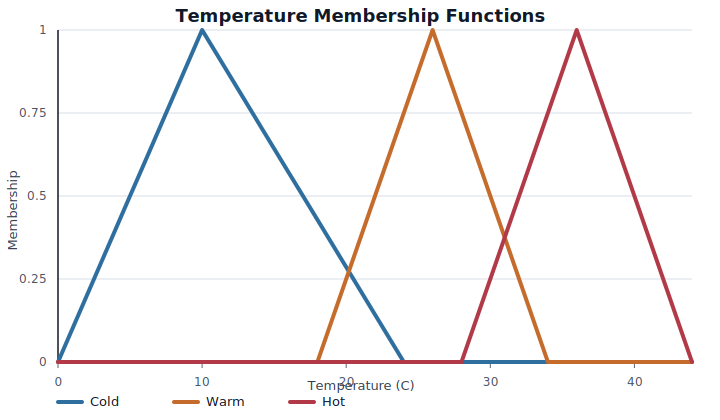

In [3]:
def build_membership_svg():
    width = 720
    height = 420
    margin_left = 58
    margin_right = 28
    margin_top = 30
    margin_bottom = 58
    plot_width = width - margin_left - margin_right
    plot_height = height - margin_top - margin_bottom

    def x_scale(value):
        return margin_left + (value / 44) * plot_width

    def y_scale(membership):
        return margin_top + (1 - membership) * plot_height

    def points_for(function):
        return " ".join(
            f"{x_scale(value):.1f},{y_scale(function(value)):.1f}"
            for value in range(45)
        )

    series = [
        ("Cold", "#2f6f9f", cold_temperature),
        ("Warm", "#c56b2c", warm_temperature),
        ("Hot", "#b23a48", hot_temperature),
    ]

    grid_lines = []
    for tick in [0, 0.25, 0.5, 0.75, 1.0]:
        y = y_scale(tick)
        grid_lines.append(
            f'<line x1="{margin_left}" y1="{y:.1f}" x2="{width - margin_right}" y2="{y:.1f}" stroke="#d7dde5" stroke-width="1" />'
        )
        grid_lines.append(
            f'<text x="{margin_left - 12}" y="{y + 4:.1f}" text-anchor="end" font-size="12" fill="#4b5563">{tick:.2g}</text>'
        )

    x_ticks = []
    for tick in [0, 10, 20, 30, 40]:
        x = x_scale(tick)
        x_ticks.append(
            f'<line x1="{x:.1f}" y1="{height - margin_bottom}" x2="{x:.1f}" y2="{height - margin_bottom + 6}" stroke="#596579" stroke-width="1" />'
        )
        x_ticks.append(
            f'<text x="{x:.1f}" y="{height - margin_bottom + 24}" text-anchor="middle" font-size="12" fill="#4b5563">{tick}</text>'
        )

    polylines = []
    legend = []
    for index, (label, color, function) in enumerate(series):
        polylines.append(
            f'<polyline points="{points_for(function)}" fill="none" stroke="{color}" stroke-width="4" stroke-linecap="round" stroke-linejoin="round" />'
        )
        legend_x = margin_left + index * 116
        legend_y = height - 18
        legend.append(f'<line x1="{legend_x}" y1="{legend_y}" x2="{legend_x + 24}" y2="{legend_y}" stroke="{color}" stroke-width="4" stroke-linecap="round" />')
        legend.append(f'<text x="{legend_x + 32}" y="{legend_y + 4}" font-size="13" fill="#111827">{label}</text>')

    return f'''
<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}" role="img" aria-label="Fuzzy temperature membership functions">
  <rect width="100%" height="100%" fill="#ffffff" />
  <text x="{width / 2}" y="22" text-anchor="middle" font-size="18" font-weight="700" fill="#111827">Temperature Membership Functions</text>
  {''.join(grid_lines)}
  <line x1="{margin_left}" y1="{height - margin_bottom}" x2="{width - margin_right}" y2="{height - margin_bottom}" stroke="#111827" stroke-width="1.5" />
  <line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{height - margin_bottom}" stroke="#111827" stroke-width="1.5" />
  {''.join(x_ticks)}
  {''.join(polylines)}
  <text x="{width / 2}" y="{height - 30}" text-anchor="middle" font-size="13" fill="#374151">Temperature (C)</text>
  <text x="17" y="{height / 2}" text-anchor="middle" font-size="13" fill="#374151" transform="rotate(-90 17 {height / 2})">Membership</text>
  {''.join(legend)}
</svg>'''


membership_svg = build_membership_svg()

try:
    from IPython.display import SVG, display
    display(SVG(membership_svg))
except ImportError:
    print(membership_svg)
